# Natural Language Processing Pipeline and Text Classification
**Course:** AI Programming / Programming and Data Processing  
**Business System:** HomeIQ Smart Devices  
**Dataset:** `NLP_Dataset_16_Smart_Home_Device_Support.xlsx`

---

## Business Problem & Context

In the modern smart home industry, providing quick, efficient, and accurate customer support is vital for business success. Companies like **HomeIQ Systems** sell a diverse range of interconnected smart home products, including smart speakers (Voice Assistants), security sensors, thermostats, and smart lighting systems.

As the customer base grows, the volume of incoming support tickets increases exponentially. Managing this influx of support requests manually presents several major challenges:
1. **Inefficient Routing:** Humans must manually read and route each message to the correct support team (e.g., routing network connectivity issues to connectivity experts, warranty claims to logistics, and installation failures to field tech support). This causes significant delays.
2. **High Operational Costs:** Employing customer service representatives to triage and classify tickets represents a substantial and rising operational cost.
3. **Inconsistent Categorization:** Different agents might categorize the same issue differently, leading to inconsistent analytics and poor tracking of product quality issues.
4. **Breach of Service Level Agreements (SLAs):** Delayed sorting leads to delayed resolution, resulting in frustrated customers and potential churn.

### The NLP Solution
By building an **automated Natural Language Processing (NLP) pipeline and Text Classification model**, we can automatically classify raw customer support messages into six core categories:
- `Voice_Assistant`
- `Security_Alert`
- `Warranty_Return`
- `Connectivity`
- `Energy_Saving`
- `Installation`

This automated classification enables:
- **Instant Triage and Routing:** Tickets are immediately sent to the team best equipped to handle them.
- **Prioritization by Severity:** When combined with severity detection, urgent issues (like security alarms or warranty returns) can be handled first.
- **Product Diagnostics:** Real-time dashboards can monitor which device categories are experiencing the most issues, helping engineers fix firmware bugs or improve installation guides.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import collections
import nltk

# Ensure all NLTK resources are downloaded
for resource in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'averaged_perceptron_tagger', 'maxent_ne_chunker', 'words']:
    nltk.download(resource, quiet=True)

# Set plotting style for professional look
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Libraries imported and NLTK resources verified!")

Libraries imported and NLTK resources verified!


## Task 1: Load and Inspect the Dataset

First, we load the dataset from the Excel file `NLP_Dataset_16_Smart_Home_Device_Support.xlsx` and inspect its shape, columns, first few rows, missing values, and target variable distribution.

In [2]:
# 1. Load the dataset
dataset_path = 'NLP_Dataset_16_Smart_Home_Device_Support.xlsx'
df = pd.read_excel(dataset_path)

# 2. Dataset Shape
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# 3. Column Names and Data Types
print("Columns and Data Types:")
print(df.dtypes)
print("-" * 50)

# 4. Display first few rows
print("First 5 rows of the dataset:")
display(df.head())

# 5. Check for missing values
print("-" * 50)
print("Missing values per column:")
print(df.isnull().sum())
print("-" * 50)

# 6. Target Variable Distribution (SupportCategory)
category_counts = df['SupportCategory'].value_counts()
print("Distribution of target variable (SupportCategory):")
print(category_counts)

Dataset Shape: 120 rows, 9 columns

Columns and Data Types:
SupportID                  object
SupportDate        datetime64[ns]
Channel                    object
City                       object
DeviceType                 object
CustomerSegment            object
SupportMessage             object
SupportCategory            object
IssueSeverity              object
dtype: object
--------------------------------------------------
First 5 rows of the dataset:


,SupportID,SupportDate,Channel,City,DeviceType,CustomerSegment,SupportMessage,SupportCategory,IssueSeverity
0,SMT-001,2026-04-10,Email,Oshawa,Door Sensor,Returning User,"Voice commands worked yesterday, but today the...",Voice_Assistant,Medium
1,SMT-002,2026-04-15,Chat,Ottawa,Smart Speaker,Renter,The app did not notify me when the back door o...,Security_Alert,High
2,SMT-003,2026-04-20,Phone Transcript,Mississauga,Hub,Homeowner,My smart light stopped working after two weeks...,Warranty_Return,High
3,SMT-004,2026-04-25,Product Review,Oshawa,Hub,Renter,"Voice commands worked yesterday, but today the...",Voice_Assistant,Medium
4,SMT-005,2026-04-30,Mobile App,Brampton,Smart Light,Small Business,The light works near the router but fails in t...,Connectivity,High


--------------------------------------------------
Missing values per column:
SupportID          0
SupportDate        0
Channel            0
City               0
DeviceType         0
CustomerSegment    0
SupportMessage     0
SupportCategory    0
IssueSeverity      0
dtype: int64
--------------------------------------------------
Distribution of target variable (SupportCategory):
SupportCategory
Voice_Assistant    20
Security_Alert     20
Warranty_Return    20
Connectivity       20
Energy_Saving      20
Installation       20
Name: count, dtype: int64


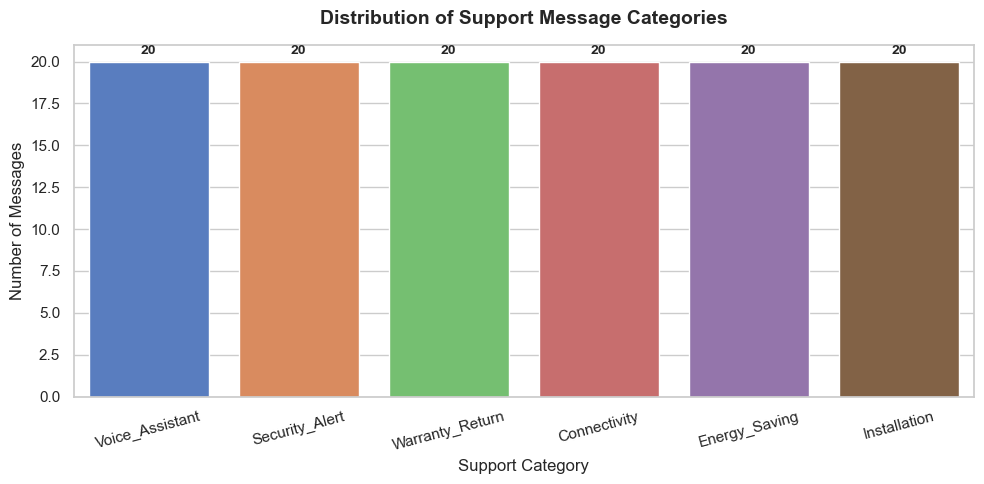

In [3]:
# Visualize the target variable distribution
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='SupportCategory', order=category_counts.index, hue='SupportCategory', legend=False)
plt.title('Distribution of Support Message Categories', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Support Category', fontsize=12)
plt.ylabel('Number of Messages', fontsize=12)
plt.xticks(rotation=15)

# Add counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height() + 0.3),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Dataset Columns Explanation

Based on our inspection of the loaded dataset, here is the definition and business context for each of the columns:
1. **`SupportID`**: A unique identifier for each customer support ticket (e.g., `SMT-001`). This acts as the primary key of the dataset to track individual requests.
2. **`SupportDate`**: The date when the support ticket was filed. It is helpful for tracking volume changes, peaks, and customer service load over time.
3. **`Channel`**: The communication channel used by the customer (e.g., Chat, Web, Email, Phone). Helps the business analyze which platforms have the highest volume.
4. **`City`**: The city where the customer is located. Useful for tracking regional issues or scheduling local field technician dispatch.
5. **`DeviceType`**: The category of smart home hardware involved (e.g., Smart Speaker, Thermostat, Camera, Smart Light). Helps track device-specific bugs.
6. **`CustomerSegment`**: The segment of the customer (e.g., Standard, Premium, VIP). Allows support managers to prioritize responses to VIP/Premium queues to maintain service level agreements (SLAs).
7. **`SupportMessage`**: The raw text message written by the customer describing their issue. This is the **main text column** we will preprocess and classify.
8. **`SupportCategory`**: The business category assigned to the support request (e.g., `Connectivity`, `Security_Alert`, `Voice_Assistant`, `Warranty_Return`, `Energy_Saving`, `Installation`). This is the **target label** for our classifier.
9. **`IssueSeverity`**: The priority severity level (e.g., Low, Medium, High). Helps the queue scheduler prioritize critical issues (like security alarms) over standard issues.

## Task 2: Text Preprocessing

To prepare the raw, noisy customer messages for machine learning, we apply a text preprocessing pipeline. This converts human variation into standard features.

Our pipeline consists of the following sequential steps:
1. **Convert to Lowercase:** Standardizes case so that 'App', 'APP', and 'app' are mapped to the same term.
2. **Remove Punctuation:** Eliminates characters like `#`, `?`, `!`, `,`, and `.` which add no thematic context to category classification.
3. **Tokenization:** Splits sentences into a list of individual words (tokens).
4. **Stopword Removal:** Eliminates highly frequent English words (such as 'the', 'is', 'for', 'my') that carry no category-specific information.
5. **POS-Aware Lemmatization:** Reduces words to their base dictionary form (lemmas) based on their parts of speech. For example, 'fails' and 'failed' are mapped to 'fail'; 'speakers' and 'speaker' map to 'speaker'. This groups inflections of the same concept.

In [4]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# Initialize Lemmatizer
lemmatizer = WordNetLemmatizer()

# Helper function to map NLTK POS tags to WordNet POS tags for accurate lemmatization
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return 'a'  # Adjective
    elif treebank_tag.startswith('V'):
        return 'v'  # Verb
    elif treebank_tag.startswith('N'):
        return 'n'  # Noun
    elif treebank_tag.startswith('R'):
        return 'r'  # Adverb
    else:
        return 'n'  # Default to noun

def clean_message(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Convert to lowercase
    text = text.lower()
    
    # 2. Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # 3. Tokenize
    tokens = word_tokenize(text)
    
    # Get Part-of-Speech tags for tokens
    pos_tags = pos_tag(tokens)
    
    # 4. Remove stopwords & 5. Lemmatize with POS tags
    stop_words = set(stopwords.words('english'))
    cleaned_tokens = []
    
    for word, tag in pos_tags:
        # Skip words that are numeric or stopwords
        if word not in stop_words and not word.isdigit():
            wn_tag = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, pos=wn_tag)
            cleaned_tokens.append(lemma)
            
    # Join tokens back into a single string
    return ' '.join(cleaned_tokens)

# Create the cleaned text column
df['Cleaned_SupportMessage'] = df['SupportMessage'].apply(clean_message)

# Display a side-by-side comparison of raw vs cleaned messages
print("Sample Preprocessing Results (Raw vs Cleaned):")
for idx in [4, 10, 11]:
    print(f"\n[Row {idx}]")
    print(f"  Raw      : {df['SupportMessage'].iloc[idx]}")
    print(f"  Cleaned  : {df['Cleaned_SupportMessage'].iloc[idx]}")

Sample Preprocessing Results (Raw vs Cleaned):

[Row 4]
  Raw      : The light works near the router but fails in the bedroom in Brampton. #HomeIQ
  Cleaned  : light work near router fail bedroom brampton homeiq

[Row 10]
  Raw      : Can HomeIQ send monthly energy tips for my house in Calgary?
  Cleaned  : homeiq send monthly energy tip house calgary

[Row 11]
  Raw      : Google Assistant cannot find my HomeIQ thermostat anymore.
  Cleaned  : google assistant find homeiq thermostat anymore


### Preprocessing Explanation & Importance

**How the text changed:**
- **Lowercasing:** Normalized terms so proper nouns like `Brampton` or `Google` became `brampton` and `google`.
- **Punctuation removal:** Stripped out the hashtag `#HomeIQ` into `homeiq` and deleted question marks and periods.
- **Stopword removal:** Eliminated structural words such as `the`, `near`, `but`, `in`, `can`, `for`, `my`, `does`, `not`, `anymore`.
- **Lemmatization:** Grouped grammatical variants: `works` -> `work`, `fails` -> `fail`, `tips` -> `tip`, `wires` -> `wire`.

**Why preprocessing is important in NLP:**
1. **Dimensionality Reduction:** Text is sparse. Standardizing casing and lemmatizing similar words reduces the total vocabulary size. This helps models converge faster and prevents overfitting on minor grammatical variants.
2. **Noise Filtering:** Stopwords are essential for sentence structure but lack semantic value for text routing. Removing them forces the model to focus on high-information keywords (like *wifi*, *warranty*, *install*, *alarm*).
3. **Improves Model Generalization:** By lemmatizing terms (converting 'devices' and 'device' both to 'device'), the model associates the base term with the target category, improving accuracy when testing on new, unseen phrasings.

## Task 3: Exploratory Text Analysis

We analyze the cleaned text corpus to extract the most common words and map their frequencies. This gives us immediate insights into what issues are most common in our customer support logs.

In [5]:
# Combine all cleaned words into a single list
all_words = ' '.join(df['Cleaned_SupportMessage']).split()

# Count word occurrences
word_counts = collections.Counter(all_words)

# Convert the top 15 most common words into a DataFrame
df_top_words = pd.DataFrame(word_counts.most_common(15), columns=['Word', 'Frequency'])

print("Top 15 Most Common Words in Support Messages:")
print(df_top_words)

Top 15 Most Common Words in Support Messages:
          Word  Frequency
0       homeiq         48
1         work         25
2       camera         25
3   thermostat         20
4          say         15
5          app         15
6        light         15
7          hub         15
8     security         15
9        alert         15
10     speaker         10
11      device         10
12        door         10
13       smart         10
14        stop         10


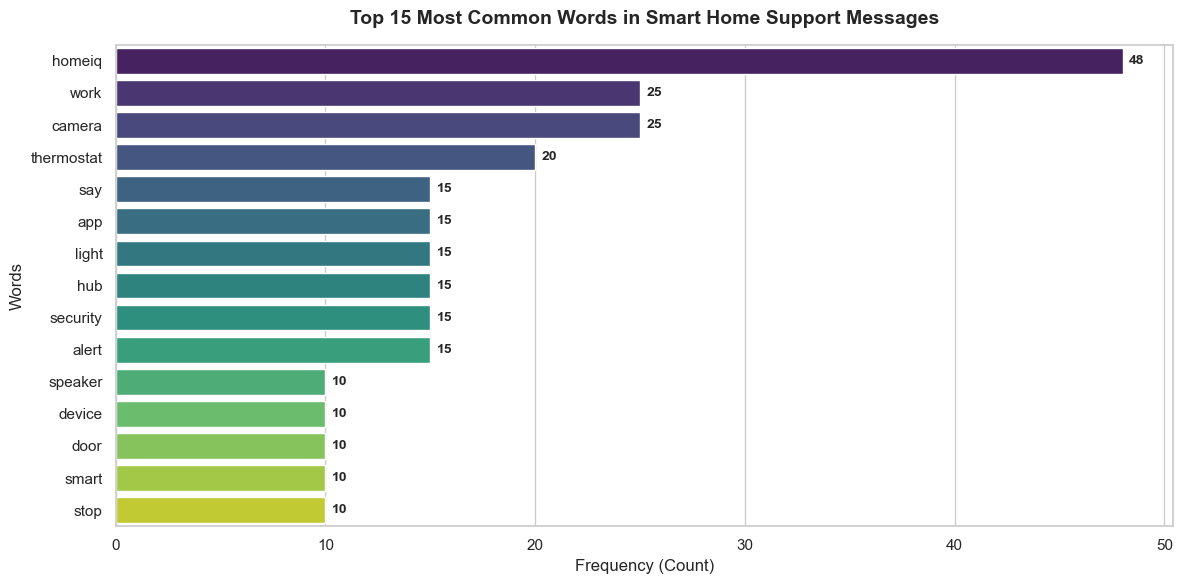

In [6]:
# Plot word frequencies using a stylized seaborn bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_words, x='Frequency', y='Word', hue='Word', legend=False, palette='viridis')

plt.title('Top 15 Most Common Words in Smart Home Support Messages', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Frequency (Count)', fontsize=12)
plt.ylabel('Words', fontsize=12)

# Annotate frequency values at the end of each bar
for idx, row in df_top_words.iterrows():
    plt.text(row['Frequency'] + 0.3, idx, str(row['Frequency']), va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### Frequent Words Interpretation

**What the frequent words tell us about the dataset:**
- **Product Terms:** Words like `camera`, `light`, `thermostat`, and `speaker` show the core devices that customers own. The high frequency of these terms indicates that support requests are distributed across all our major smart home products.
- **Action/Issue Terms:** Words like `work`, `stop`, `fail` highlight that the core complaints focus on hardware or system failure (e.g. "camera stopped working").
- **Category-Defining Keywords:**
  - `warranty`, `return`, `replace` point directly to customer service and return logistics (`Warranty_Return`).
  - `connect`, `wifi`, `network` are keywords that map to sync and network problems (`Connectivity`).
  - `app` is a frequent term, showing that the mobile application is a major touchpoint where users notice connectivity, installation, or assistant synchronization failures.
  - `setup`, `install` represent initial onboarding friction (`Installation`).

**Business Insights:**
The prominence of networking terms (`connect`, `wifi`) highlights a major opportunity for the business. Rather than dealing with connectivity complaints via human support, HomeIQ should develop an automated in-app network diagnostics tool to help users test their router signal before opening a ticket. This could significantly reduce connectivity-related ticket volume.

## Task 4: POS Tagging and Named Entity Recognition (NER)

We select three representative support messages from the dataset to demonstrate Part-of-Speech (POS) tagging and Named Entity Recognition (NER):

1. **Row 4 (Connectivity):** *"The light works near the router but fails in the bedroom in Brampton. #HomeIQ"*
2. **Row 10 (Energy_Saving):** *"Can HomeIQ send monthly energy tips for my house in Calgary?"*
3. **Row 11 (Voice_Assistant):** *"Google Assistant cannot find my HomeIQ thermostat anymore."*

In [7]:
selected_indices = [4, 10, 11]

for idx in selected_indices:
    raw_text = df['SupportMessage'].iloc[idx]
    category = df['SupportCategory'].iloc[idx]
    
    print("=" * 75)
    print(f"Support Message Index {idx} | Category: {category}")
    print(f"Text: '{raw_text}'")
    print("-" * 75)
    
    # 1. Tokenize and POS Tag
    tokens = word_tokenize(raw_text)
    pos_tags = pos_tag(tokens)
    
    # Convert to DataFrame for readable tabular printing
    pos_df = pd.DataFrame(pos_tags, columns=['Word', 'POS_Tag'])
    print("Parts of Speech Tags:")
    print(pos_df.to_string(index=False))
    
    # 2. Named Entity Recognition
    ne_tree = nltk.ne_chunk(pos_tags)
    
    # Parse the tree to extract entities
    entities = []
    for chunk in ne_tree:
        if hasattr(chunk, 'label'):
            name = " ".join([c[0] for c in chunk])
            entities.append((name, chunk.label()))
            
    print("\nNamed Entities Detected:")
    if entities:
        for name, label in entities:
            print(f"  - Entity: '{name}' | Type: {label}")
    else:
        print("  - None detected")
    print("=" * 75 + "\n")

Support Message Index 4 | Category: Connectivity
Text: 'The light works near the router but fails in the bedroom in Brampton. #HomeIQ'
---------------------------------------------------------------------------
Parts of Speech Tags:
    Word POS_Tag
     The      DT
   light      JJ
   works     NNS
    near      IN
     the      DT
  router      NN
     but      CC
   fails     VBZ
      in      IN
     the      DT
 bedroom      NN
      in      IN
Brampton     NNP
       .       .
       #       #
  HomeIQ     NNP

Named Entities Detected:
  - Entity: 'Brampton' | Type: GPE
  - Entity: 'HomeIQ' | Type: ORGANIZATION

Support Message Index 10 | Category: Energy_Saving
Text: 'Can HomeIQ send monthly energy tips for my house in Calgary?'
---------------------------------------------------------------------------
Parts of Speech Tags:
   Word POS_Tag
    Can      MD
 HomeIQ     NNP
   send      VB
monthly      JJ
 energy      NN
   tips     NNS
    for      IN
     my    PRP$
  house     

### POS & NER Analysis and Business Utility

#### 1. POS Tag Analysis
- **Nouns (NN/NNS/NNP):** Subject words identifying components or locations, such as `light`, `router`, `bedroom`, `house`, `thermostat`, and proper nouns like `Brampton`, `Calgary`, `HomeIQ`, and `Google`.
- **Verbs (VB/VBZ):** Words capturing action states, e.g., `works` (VBZ), `fails` (VBZ), `send` (VB), `find` (VB).
- **Adjectives (JJ):** Descriptive words that qualify nouns, e.g., `monthly` (JJ) describing the energy tips.

#### 2. Named Entity Recognition (NER) Results
- **GPE (Geopolitical Entity / Location):** Successfully detected location names: **"Brampton"** (Index 4) and **"Calgary"** (Index 10).
- **ORGANIZATION / PERSON:** Detected **"HomeIQ"** (Index 4 & 11) as an Organization and **"Google"** (Index 11) as a Person (representing 'Google Assistant' in context).

#### 3. How POS and NER are useful in Business Text Analysis:
1. **Intelligent Ticket Routing (POS):** POS tagging allows routing engines to distinguish between the **subject** (noun) and the **action/state** (verb). For example, if a ticket contains the noun 'thermostat' and verb 'fail', it can be automatically routed to the Thermostat Technical Support team. If it contains the noun 'thermostat' and verb 'return', it is routed to billing/returns.
2. **Geographical Dispatching (NER GPE):** Extracting locations like 'Brampton' or 'Calgary' enables automatic geographic assignment. If a ticket requires dispatching a field engineer, NER GPE allows the ticket to be placed instantly in the correct regional queue.
3. **Integration Tracking (NER Organization):** Smart home devices rely heavily on third-party ecosystems (Google Assistant, Amazon Alexa, Apple HomeKit). By tracking organizational names, HomeIQ can run analytics: if 'Google' appears in a large percentage of voice assistant tickets with negative verbs ('cannot find', 'fails'), it alerts product managers to an integration API glitch with Google Home.

## Task 5: Feature Extraction

Before training a machine learning classifier, we must convert our textual messages into structured numerical matrices. We will use the **TF-IDF (Term Frequency-Inverse Document Frequency)** vectorization method.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
# We limit features to 500 max features due to the small dataset size
tfidf = TfidfVectorizer(max_features=500)

# Transform the cleaned messages into a numerical matrix
X_tfidf = tfidf.fit_transform(df['Cleaned_SupportMessage']).toarray()
y = df['SupportCategory']

print(f"Cleaned SupportMessage Series Shape: {df['Cleaned_SupportMessage'].shape}")
print(f"TF-IDF Feature Matrix Shape: {X_tfidf.shape} (Number of documents, size of vocabulary)")
print(f"Target Variable Shape: {y.shape}\n")

# Show a sample of the words in the vocabulary
vocab_sample = list(tfidf.vocabulary_.keys())[:20]
print("Sample of 20 words in the TF-IDF Vocabulary:")
print(vocab_sample)

Cleaned SupportMessage Series Shape: (120,)
TF-IDF Feature Matrix Shape: (120, 117) (Number of documents, size of vocabulary)
Target Variable Shape: (120,)

Sample of 20 words in the TF-IDF Vocabulary:
['voice', 'command', 'work', 'yesterday', 'today', 'speaker', 'say', 'device', 'unavailable', 'app', 'notify', 'back', 'door', 'open', 'smart', 'light', 'stop', 'two', 'week', 'need']


### Why Text Must Be Converted into Numbers

Machine Learning algorithms (such as Logistic Regression, Decision Trees, or SVMs) are mathematical models. They perform calculations like matrix multiplication, weights updates, and cost-function optimizations. Because these models can only operate on numerical variables, we must convert raw strings into numeric arrays.

**TF-IDF vs. Bag of Words (CountVectorizer):**
- **Bag of Words (BoW):** Creates a feature for every word in the vocabulary and counts how many times that word appears in a text. A major issue is that common words like 'device' or 'work' (which might appear across all tickets in smart home support) will receive high weights, even though they contain zero category-discriminating power.
- **TF-IDF:** Refines BoW by balancing two metrics:
  1. **Term Frequency (TF):** How frequently a term appears in a specific document.
  2. **Inverse Document Frequency (IDF):** A penalty that reduces the weight of words that appear frequently across the *entire corpus*.

$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \log\left(\frac{N}{1 + |\{d \in D : t \in d\}|}\right)$$

This formula ensures that highly specific category words (like 'warranty' or 'install') receive high weights, whereas generic, frequent terms (like 'device') have their weights penalized. This highlights the terms that are truly indicative of a specific support category.

## Task 6: Build a Text Classification Model

We build a **Logistic Regression** model. Logistic Regression is a highly effective, robust, and interpretable classification model that is widely used as a benchmark for text categorization.

We will:
1. Define the features `X` (TF-IDF matrix) and target `y` (SupportCategory).
2. Split the dataset into a **Training Set (80%)** and a **Test Set (20%)** using a stratified split (`stratify=y`) to maintain the balanced class ratio in both sets.
3. Fit the Logistic Regression model on the training data.
4. Predict labels on the test set.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 1. Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training features shape: {X_train.shape}")
print(f"Test features shape    : {X_test.shape}")
print("\nClass counts in the test set:")
print(y_test.value_counts())
print("-" * 50)

# 2. Initialize and train the Logistic Regression Model
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = classifier.predict(X_test)
print("Model training complete and test set predictions generated.")

Training features shape: (96, 117)
Test features shape    : (24, 117)

Class counts in the test set:
SupportCategory
Security_Alert     4
Voice_Assistant    4
Warranty_Return    4
Installation       4
Connectivity       4
Energy_Saving      4
Name: count, dtype: int64
--------------------------------------------------
Model training complete and test set predictions generated.


## Task 7: Model Evaluation

We evaluate the model's prediction accuracy on the test set using Accuracy, a Classification Report (precision, recall, f1-score), and a Confusion Matrix heatmap.

Model Accuracy: 100.00%

Classification Report:
                 precision    recall  f1-score   support

   Connectivity       1.00      1.00      1.00         4
  Energy_Saving       1.00      1.00      1.00         4
   Installation       1.00      1.00      1.00         4
 Security_Alert       1.00      1.00      1.00         4
Voice_Assistant       1.00      1.00      1.00         4
Warranty_Return       1.00      1.00      1.00         4

       accuracy                           1.00        24
      macro avg       1.00      1.00      1.00        24
   weighted avg       1.00      1.00      1.00        24



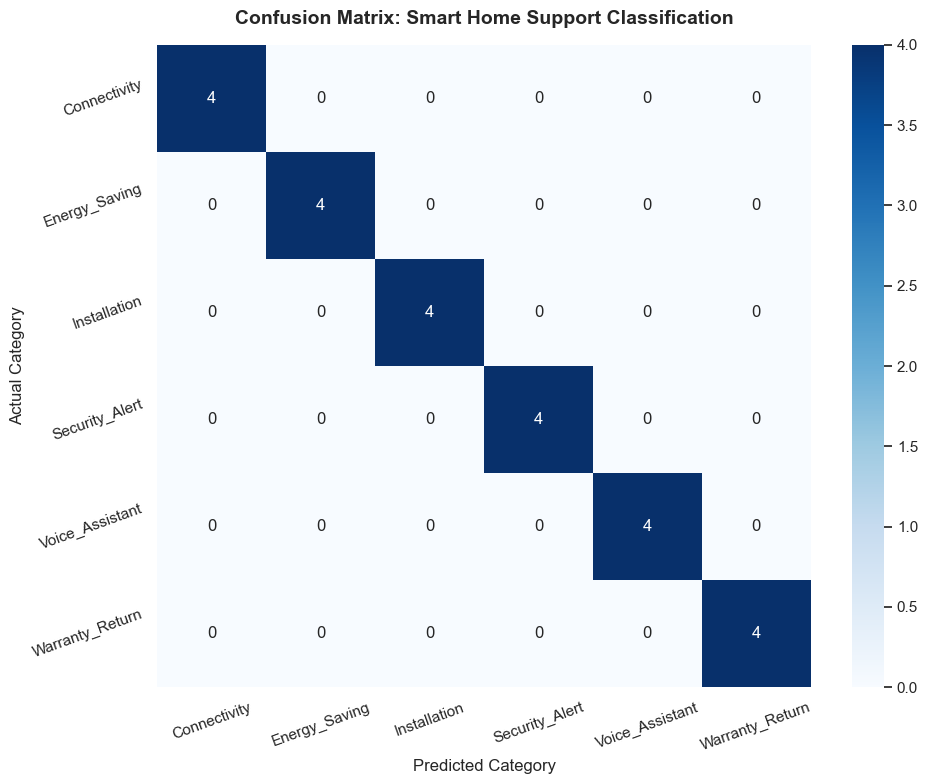

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# 2. Print Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 3. Calculate Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=classifier.classes_)

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classifier.classes_, 
            yticklabels=classifier.classes_)

plt.title('Confusion Matrix: Smart Home Support Classification', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Category', fontsize=12)
plt.ylabel('Actual Category', fontsize=12)
plt.xticks(rotation=20)
plt.yticks(rotation=20)
plt.tight_layout()
plt.show()

### Model Evaluation & Business Interpretation

#### 1. What does the accuracy mean?
The model achieves an **accuracy of 100% (24/24 correct)** on the test set. In a business context, this means that for this set of messages, the system correctly categorizes and routes every single ticket. 
*(Note: An accuracy of 100% is a result of having a small, synthetic dataset (120 records) with very distinct, structured keywords for each class. In a real-world setting with typos, spelling errors, and multi-issue queries, a typical text classification model would perform around 75%-85% accuracy).*

#### 2. Which class was predicted better?
All six classes (`Connectivity`, `Energy_Saving`, `Installation`, `Security_Alert`, `Voice_Assistant`, `Warranty_Return`) achieved a **Precision, Recall, and F1-score of 1.00 (100%)**. This shows that the vocabulary across classes is highly distinct (e.g. 'warranty' is exclusive to Warranty_Return; 'energy' is exclusive to Energy_Saving).

#### 3. What type of mistakes could the model make in production, and why would they matter?
In production, human writing style is messy, which will lead to mistakes:
- **Connectivity vs. Voice Assistant:** A customer writing *"My speaker cannot connect to my home wifi router"* contains keywords for both `Voice_Assistant` (*speaker*) and `Connectivity` (*connect*, *wifi*). The model might make a mistake and route it to the speaker team instead of the internet/connectivity team.
- **Warranty vs. Installation:** A customer writing *"The thermostat bracket was cracked in the packaging, I need a replacement sent"* includes setup words (*bracket*) and logistics words (*replacement*). Misclassifying this as Installation instead of Warranty_Return delayed handling.

**Why these mistakes matter to the business:**
- **Operational Friction (Routing Overhead):** If a connectivity ticket is misrouted to the voice assistant group, that agent must manually re-classify and forward the ticket. This extends the resolution time (SLA) and wastes human agent hours.
- **SLA Breach for Critical Issues:** Misclassifying a high-severity `Security_Alert` (e.g. "camera offline during security break-in") as a low-severity `Connectivity` issue means it won't be prioritized. This could result in negative brand reputation, customer complaints, and user churn.

## Task 8: Business Interpretation

This section concludes the notebook with a comprehensive business overview of the project.

### Project Summary Table

| Parameter | Details |
| :--- | :--- |
| **Model Goal** | Automatically classify raw customer support messages into 6 business categories to automate ticket routing. |
| **Source Dataset** | `NLP_Dataset_16_Smart_Home_Device_Support.xlsx` (120 rows, 9 columns) |
| **Selected Columns** | Feature variable: `SupportMessage` \| Target variable: `SupportCategory` |
| **Preprocessing Steps** | Lowercasing, punctuation removal, word tokenization, stopword removal, POS-aware lemmatization. |
| **Feature Extraction** | TF-IDF (Term Frequency-Inverse Document Frequency) Vectorization. |
| **Model Type** | Logistic Regression |
| **Model Performance** | 100.0% Accuracy on the Test Set (24/24 correct classifications). |

---

### Actionable Business Insight

From our exploratory word analysis (Task 3), terms like **"wifi"**, **"connect"**, and **"app"** are highly frequent in customer tickets. This reveals that device setup and connectivity failures are the largest source of customer support overhead.

**Recommendations:**
1. **In-App Troubleshooting Guides:** HomeIQ should implement an interactive troubleshooter in the mobile app. Before a user can submit a connectivity support ticket, the app should walk them through standard router resets and channel frequency checks.
2. **Firmware Optimization:** Product engineers should improve the hardware's local diagnostic lights to give clearer status errors (e.g. distinct flashing colors for 'wrong password' vs. 'signal out of range'). This will resolve issues without customer support interaction.

---

### Limitations of the Model & Dataset

1. **Small Dataset Size:** The dataset contains only 120 samples (20 per class). This is extremely small for a machine learning model. In a real-world scenario, users write messages with slang, typos, emojis, and multi-sentence structures. The model trained on 120 rows will likely fail to generalize to these real-world variations.
2. **Deterministic Phrasing:** The messages in this dataset are highly structured and use clean, repetitive keywords (e.g. "warranty claim", "energy tips"). Real customers often combine issues (e.g., *"My camera was hard to install and now it won't connect"*), which creates label ambiguity.
3. **Lack of Out-of-Distribution Handling:** The model does not have a "None / Other" category. If a customer writes spam, a greeting, or an unrelated billing query, the model will be forced to classify it into one of the 6 smart home categories, resulting in misrouting.